# Ridge Regression from Scratch 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

We generate a dataset with 5 features and 1 target variable.

In [8]:
def generate_data(n_samples=100):
    X = np.random.rand(n_samples, 5)
    true_weights = np.array([2.5, -1.0, -9.0, 0.5, 4.0]) # Note one weight is zero
    true_bias = 3.0
    
    y = X @ true_weights + true_bias + np.random.normal(0, 0.9, n_samples)
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,0.398289,0.296755,0.431874,0.778949,0.583234,2.675994
1,0.301522,0.808949,0.802586,0.622560,0.440680,-3.750909
2,0.281653,0.173527,0.576170,0.663156,0.680566,4.254862
3,0.104046,0.890241,0.036596,0.161187,0.893573,7.009349
4,0.851821,0.004659,0.864353,0.991545,0.692725,1.088068


## 2. Implementation

L2 Penalty: $Cost = MSE + \lambda \sum w^2$

In [ ]:
class RidgeRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, l2_penalty=1.0):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.lambda = l2_penalty
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) + (2 * self.lambda * self.weights)
            db = (1/n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            cost = (1/(2*n_samples)) * np.sum((y_pred - y)**2) + self.lambda * np.sum(self.weights**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## 3. Training the Model

In [25]:
model = RidgeRegressionGD(learning_rate=0.01, n_iterations=2000, l2_penalty=0.4)
model.fit(X, y)

print(f"Final Weights: {model.weights}")
print(f"Final Bias: {model.bias}")

Final Weights: [ 0.28500806 -0.1996044  -0.86924615  0.00856392  0.36269391]
Final Bias: 1.590709603908405


## 4. Visualization of Results

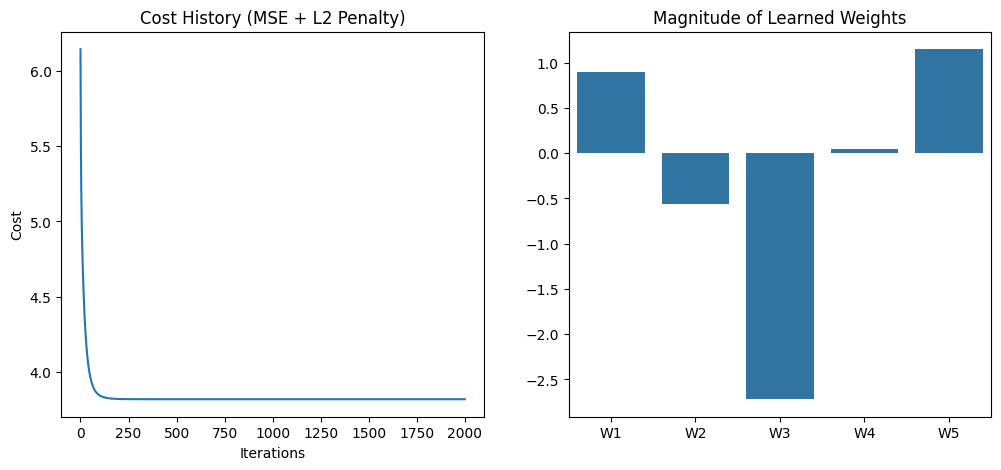

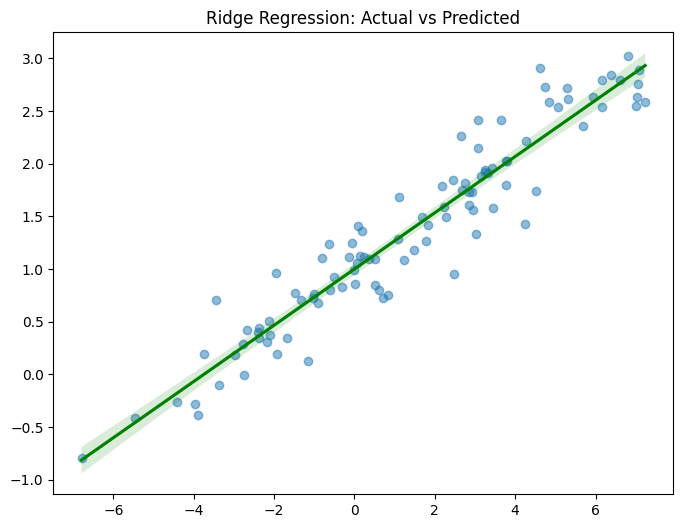

In [ ]:
y_pred = model.predict(X)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.cost_history)
plt.title("Cost History (MSE + L2 Penalty)")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.subplot(1, 2, 2)
sns.barplot(x=[f"W{i+1}" for i in range(5)], y=model.weights)
plt.title("Magnitude of Learned Weights")
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()